In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Preprocess data
# Reshape to (samples, height, width, channels)
x_train = x_train.reshape(-1, 32, 32, 3) / 255.0
x_test = x_test.reshape(-1, 32, 32, 3) / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Train the model
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc*100:.2f}%")

model.save("cifar_model.h5")


class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

fashion_model = load_model("cifar_model.h5")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 89ms/step - accuracy: 0.3745 - loss: 1.7192 - val_accuracy: 0.5678 - val_loss: 1.2311
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.5852 - loss: 1.1756 - val_accuracy: 0.6346 - val_loss: 1.0331
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 91ms/step - accuracy: 0.6426 - loss: 1.0194 - val_accuracy: 0.6456 - val_loss: 1.0075
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.6849 - loss: 0.8989 - val_accuracy: 0.6876 - val_loss: 0.9148
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.7205 - loss: 0.8122 - val_accuracy: 0.6836 - val_loss: 0.9296
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 88ms/step - accuracy: 0.7432 - loss: 0.7445 - val_accuracy: 0.7064 - val_loss: 0.8649
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.7700 - loss: 0.6697 - val_accuracy: 0.7152 - val_loss: 0.8707
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.7934 - loss: 0.5996 - 

Test accuracy: 69.89%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


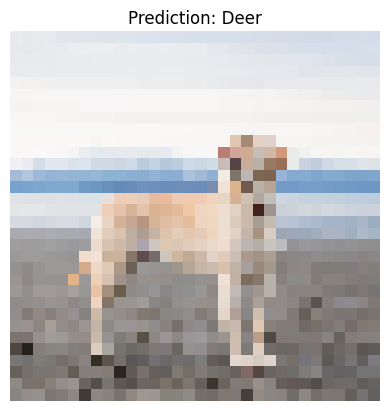

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(
    "dog.avif",
    color_mode="rgb",
    target_size=(32, 32)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = fashion_model.predict(img_array)
predicted_class = np.argmax(prediction)

plt.imshow(img)
plt.title(f"Prediction: {class_names[predicted_class]}")
plt.axis("off")
plt.show()